# quantadesh v0.2.1 : Complete Verified Notebook
**by Adesh Patel** | Every import verified against actual source code.

#  0: INSTALL

In [ ]:
!pip install quantadesh==0.2.1 matplotlib -q
import quantadesh
print(f"quantadesh {quantadesh.__version__} ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 kB 2.4 MB/s eta 0:00:00
quantadesh 0.2.1 ready!


---
## 1 · Options Pricing : 6 Models

In [ ]:
from quantadesh.models.black_scholes import bs_price, bs_implied_vol
from quantadesh.models.binomial      import binomial_price
from quantadesh.models.monte_carlo   import mc_price
from quantadesh.models.heston        import heston_price
from quantadesh.models.bachelier     import bachelier_price
from quantadesh.models.black76       import black76_price

S, K, T, r, sigma = 100, 105, 1.0, 0.05, 0.20

# Black-Scholes (bs_price handles call and put)
call = bs_price(S, K, T, r, sigma, option_type='call')
put  = bs_price(S, K, T, r, sigma, option_type='put')
print(f"Black-Scholes   call={call:.4f}  put={put:.4f}")

# Binomial Tree
bc = binomial_price(S, K, T, r, sigma, steps=200, option_type='call')
print(f"Binomial (200)  call={bc:.4f}")

# Monte Carlo
mc = mc_price(S, K, T, r, sigma, option_type='call', paths=100_000, seed=42)
print(f"Monte Carlo     {mc}")

# Heston Stochastic Volatility
hc = heston_price(S, K, T, r,
                  v0=0.04, kappa=2.0, theta=0.04,
                  sigma=0.3, rho=-0.7, option_type='call')
print(f"Heston          call={hc:.4f}")

# Bachelier : sigma is the absolute (normal) vol
bac = bachelier_price(S, K, T, r, sigma=S*sigma, option_type='call')
print(f"Bachelier       call={bac:.4f}")

# Black-76 : for futures/bond options, F is the forward price
F   = S * (1 + r)**T
b76 = black76_price(F, K, T, r, sigma, option_type='call')
print(f"Black-76        call={b76:.4f}")

# Implied Volatility Solver
iv = bs_implied_vol(8.50, S, K, T, r, option_type='call')
print(f"\nMarket price=8.50  →  Implied vol = {iv:.4%}")

Black-Scholes   call=8.0214  put=7.9004
Binomial (200)  call=8.0260
Monte Carlo     MCResult(price=8.0369, se=0.041908, paths=100000, ci95=(7.9548, 8.1190))
Heston          call=7.6788
Bachelier       call=5.4476
Black-76        call=7.9559

Market price=8.50  →  Implied vol = 21.2069%


---
## 2 · Exotic Options

In [ ]:
from quantadesh.exotics.asian    import asian_price
from quantadesh.exotics.barrier  import barrier_price
from quantadesh.exotics.lookback import lookback_price
from quantadesh.exotics.digital  import digital_price

S, K, T, r, sigma = 100, 105, 1.0, 0.05, 0.20

# Asian arithmetic average
asian_arith = asian_price(S, K, T, r, sigma, option_type='call',
                           average_type='arithmetic', paths=50_000, seed=42)
print(f"Asian (arith)   : {asian_arith}")

# Asian geometric average
asian_geo = asian_price(S, K, T, r, sigma, option_type='call',
                         average_type='geometric', paths=50_000, seed=42)
print(f"Asian (geom)    : {asian_geo}")

# Barrier : Up-and-Out (knocked out if spot >= H=120)
uao = barrier_price(S, K, H=120, T=T, r=r, sigma=sigma,
                    barrier_type='up-and-out', option_type='call', seed=42)
print(f"Barrier up-out  : {uao}")

# Barrier : Down-and-In (activated if spot <= H=85)
dai = barrier_price(S, K, H=85, T=T, r=r, sigma=sigma,
                    barrier_type='down-and-in', option_type='put', seed=42)
print(f"Barrier down-in : {dai}")

# Lookback : floating strike, call pays S_T - min(path)
lb = lookback_price(S, T, r, sigma, option_type='call', paths=50_000, seed=42)
print(f"Lookback call   : {lb}")

# Digital : pays $1 cash if S_T > K
dig = digital_price(S, K, T, r, sigma, cash=1.0, option_type='call')
print(f"Digital call    : {dig:.4f}  (prob of finishing ITM)")

Asian (arith)   : MCResult(price=3.5627, se=0.028833, paths=50000, ci95=(3.5062, 3.6192))
Asian (geom)    : MCResult(price=3.3819, se=0.027571, paths=50000, ci95=(3.3278, 3.4359))
Barrier up-out  : MCResult(price=0.6424, se=0.009497, paths=50000, ci95=(0.6238, 0.6611))
Barrier down-in : MCResult(price=6.1188, se=0.047397, paths=50000, ci95=(6.0259, 6.2117))
Lookback call   : MCResult(price=16.3212, se=0.065091, paths=50000, ci95=(16.1936, 16.4488))
Digital call    : 0.4400  (prob of finishing ITM)


---
## 3 · Greeks

In [ ]:
# NOTE: only bs_greeks() exists in analytical : no separate delta/gamma/vega functions
from quantadesh.greeks.analytical import bs_greeks
from quantadesh.greeks.numerical  import numerical_greeks
from quantadesh.models.black_scholes import bs_price

S, K, T, r, sigma = 100, 105, 1.0, 0.05, 0.20

# All Greeks in one call : returns GreeksResult object
g = bs_greeks(S, K, T, r, sigma, option_type='call')
print("=== Analytical Greeks ===")
print(f"  Delta  {g.delta:+.4f}  : price moves per $1 spot move")
print(f"  Gamma  {g.gamma:+.4f}  : delta changes per $1 spot move")
print(f"  Vega   {g.vega:+.4f}  : price changes per 1% vol move")
print(f"  Theta  {g.theta:+.4f}  : price decay per day")
print(f"  Rho    {g.rho:+.4f}  : price changes per 1% rate move")

# Access individual Greeks from the result object
print(f"\n  delta={g.delta:.4f}  gamma={g.gamma:.4f}  vega={g.vega:.4f}")

# Put Greeks
gp = bs_greeks(S, K, T, r, sigma, option_type='put')
print(f"\n  Put delta={gp.delta:.4f}  (negative for puts)")

# Numerical Greeks : pass any pricer as the first argument
ng = numerical_greeks(bs_price, S, K, T, r, sigma, option_type='call')
print("\n=== Numerical Greeks (finite-difference) ===")
print(f"  delta={ng.delta:.4f}  gamma={ng.gamma:.4f}  vega={ng.vega:.4f}")
print(f"  theta={ng.theta:.4f}  rho={ng.rho:.4f}")

=== Analytical Greeks ===
  Delta  +0.5422  — price moves per $1 spot move
  Gamma  +0.0198  — delta changes per $1 spot move
  Vega   +0.3967  — price changes per 1% vol move
  Theta  -0.0172  — price decay per day
  Rho    +0.4620  — price changes per 1% rate move

  delta=0.5422  gamma=0.0198  vega=0.3967

  Put delta=-0.4578  (negative for puts)

=== Numerical Greeks (finite-difference) ===
  delta=0.5422  gamma=0.0198  vega=0.3967
  theta=-0.0172  rho=0.4620


---
## 4 · Portfolio Optimization

In [ ]:
from quantadesh.portfolio.markowitz       import min_variance, max_sharpe, efficient_frontier
from quantadesh.portfolio.black_litterman import black_litterman
from quantadesh.portfolio.capm            import capm_beta, capm_expected_return
import numpy as np

assets = ['AAPL', 'MSFT', 'GOOGL', 'JPM', 'GLD']
mu  = np.array([0.15, 0.13, 0.12, 0.10, 0.05])
cov = np.array([
    [0.0400, 0.0180, 0.0150, 0.0080, -0.0020],
    [0.0180, 0.0324, 0.0140, 0.0090, -0.0015],
    [0.0150, 0.0140, 0.0289, 0.0070, -0.0010],
    [0.0080, 0.0090, 0.0070, 0.0225,  0.0005],
    [-0.002,-0.0015,-0.0010, 0.0005,  0.0196],
])
rf = 0.04

# Minimum Variance Portfolio
mvp = min_variance(mu, cov, assets=assets, rf=rf)
print("=== Minimum Variance ===")
for a, w in zip(assets, mvp.weights):
    print(f"  {a:<6} {w*100:5.1f}%")
print(f"  Return={mvp.expected_return:.2%}  Vol={mvp.volatility:.2%}  Sharpe={mvp.sharpe:.3f}")

# Maximum Sharpe Portfolio
msp = max_sharpe(mu, cov, rf=rf, assets=assets)
print("\n=== Maximum Sharpe ===")
for a, w in zip(assets, msp.weights):
    print(f"  {a:<6} {w*100:5.1f}%")
print(f"  Return={msp.expected_return:.2%}  Vol={msp.volatility:.2%}  Sharpe={msp.sharpe:.3f}")

# Efficient Frontier
frontier = efficient_frontier(mu, cov, rf=rf, n_points=50)
print(f"\n=== Efficient Frontier ===")
print(f"  Vol range    : {frontier.volatilities.min():.2%} -> {frontier.volatilities.max():.2%}")
print(f"  Return range : {frontier.returns.min():.2%} -> {frontier.returns.max():.2%}")
print(f"  Best Sharpe  : {frontier.sharpes.max():.3f}")

# Black-Litterman
mkt_w = np.array([0.30, 0.25, 0.20, 0.15, 0.10])
P = np.array([[1, -1, 0, 0, 0],
              [0,  0, 1, 0, 0]])
Q = np.array([0.02, 0.14])
bl_mu = black_litterman(cov, mkt_w, P, Q)
print("\n=== Black-Litterman Returns ===")
for a, m in zip(assets, bl_mu):
    print(f"  {a:<6} {m:.2%}")

# CAPM
np.random.seed(0)
mkt = np.random.normal(0.0004, 0.012, 252)
stk = 1.2 * mkt + np.random.normal(0, 0.008, 252)
b   = capm_beta(stk, mkt)
er  = capm_expected_return(b, rf=0.04, market_return=0.10)
print(f"\n=== CAPM ===\n  Beta={b:.3f}  Expected return={er:.2%}")

=== Minimum Variance ===
  AAPL     6.6%
  MSFT    10.5%
  GOOGL   15.2%
  JPM     24.8%
  GLD     42.8%
  Return=8.81%  Vol=9.04%  Sharpe=0.532

=== Maximum Sharpe ===
  AAPL    27.7%
  MSFT    18.1%
  GOOGL   19.0%
  JPM     22.0%
  GLD     13.3%
  Return=11.64%  Vol=11.39%  Sharpe=0.671

=== Efficient Frontier ===
  Vol range    : 9.04% -> 20.00%
  Return range : 5.00% -> 15.00%
  Best Sharpe  : 0.671

=== Black-Litterman Returns ===
  AAPL   8.12%
  MSFT   6.66%
  GOOGL  8.85%
  JPM    3.60%
  GLD    0.03%

=== CAPM ===
  Beta=1.186  Expected return=11.12%


---
## 5 · Risk : VaR, CVaR, Drawdown

In [ ]:
from quantadesh.risk.var      import historical_var, parametric_var, monte_carlo_var
from quantadesh.risk.cvar     import historical_cvar, parametric_cvar
from quantadesh.risk.drawdown import max_drawdown, drawdown_series
import numpy as np

np.random.seed(42)
returns = np.random.normal(0.0008, 0.015, 252)

# VaR : 3 methods
h_var  = historical_var( returns, confidence=0.95)
p_var  = parametric_var( returns, confidence=0.95)
mc_var = monte_carlo_var(mu=returns.mean(), sigma=returns.std(),
                          confidence=0.95, paths=100_000, seed=42)
print("=== Value at Risk (95%) ===")
print(f"  Historical  : {h_var.value:.4f}")
print(f"  Parametric  : {p_var.value:.4f}")
print(f"  Monte Carlo : {mc_var.value:.4f}")

# CVaR
h_cvar = historical_cvar(returns, confidence=0.95)
p_cvar = parametric_cvar(returns, confidence=0.95)
print("\n=== CVaR / Expected Shortfall (95%) ===")
print(f"  Historical  : {h_cvar.value:.4f}")
print(f"  Parametric  : {p_cvar.value:.4f}")

# Drawdown
mdd = max_drawdown(returns)
dd  = drawdown_series(returns)
print(f"\n=== Drawdown ===")
print(f"  Max drawdown    : {mdd:.2%}")
print(f"  Avg drawdown    : {dd.mean():.2%}")
print(f"  Days underwater : {(dd < 0).sum()} / {len(dd)}")

=== Value at Risk (95%) ===
  Historical  : 0.0216
  Parametric  : 0.0231
  Monte Carlo : 0.0233

=== CVaR / Expected Shortfall (95%) ===
  Historical  : 0.0270
  Parametric  : 0.0292

=== Drawdown ===
  Max drawdown    : -19.53%
  Avg drawdown    : -9.55%
  Days underwater : 238 / 252


---
## 6 · Fixed Income

In [ ]:
from quantadesh.fixed_income.bond  import bond_price, ytm, duration, modified_duration, convexity
from quantadesh.fixed_income.curve import YieldCurve

face, coupon_rate, years, ytm_rate = 1000, 0.06, 10, 0.055

price = bond_price(face, coupon_rate, ytm_rate, years, freq=2)
mac_d = duration(face, coupon_rate, ytm_rate, years, freq=2)
mod_d = modified_duration(face, coupon_rate, ytm_rate, years, freq=2)
conv  = convexity(face, coupon_rate, ytm_rate, years, freq=2)

print("=== Bond Analytics ===")
print(f"  Price              : ${price:.2f}")
print(f"  Macaulay duration  : {mac_d:.4f} years")
print(f"  Modified duration  : {mod_d:.4f}")
print(f"  Convexity          : {conv:.4f}")

# YTM solver
implied_ytm = ytm(1038.0, face, coupon_rate, years, freq=2)
print(f"  Market price=1038  -> YTM = {implied_ytm:.4%}")

# Rate shock: +100bps
dy = 0.01
dp = -mod_d * dy * price + 0.5 * conv * dy**2 * price
print(f"  Price change (+100bps shock): ${dp:.2f}")

# Yield Curve
tenors = [0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30]
rates  = [0.043, 0.044, 0.046, 0.047, 0.047, 0.048, 0.049, 0.050, 0.051, 0.052]
curve  = YieldCurve(tenors, rates)
print("\n=== Yield Curve ===")
print(f"  Zero rate  5yr  : {curve.zero_rate(5):.4%}")
print(f"  Zero rate  10yr : {curve.zero_rate(10):.4%}")
print(f"  Discount factor 5yr : {curve.discount_factor(5):.4f}")
print(f"  1y fwd rate in 1y   : {curve.forward_rate(1, 2):.4%}")

=== Bond Analytics ===
  Price              : $1038.07
  Macaulay duration  : 7.7122 years
  Modified duration  : 7.5058
  Convexity          : 69.7115
  Market price=1038  -> YTM = 5.5009%
  Price change (+100bps shock): $-74.30

=== Yield Curve ===
  Zero rate  5yr  : 4.8000%
  Zero rate  10yr : 5.0000%
  Discount factor 5yr : 0.7866
  1y fwd rate in 1y   : 4.8000%


---
## 7 · Interest Rate Models

In [ ]:
from quantadesh.rates.vasicek    import vasicek_simulate, vasicek_zcb_price
from quantadesh.rates.cir        import cir_simulate, cir_zcb_price
from quantadesh.rates.hull_white import hull_white_simulate
import numpy as np

r0 = 0.05

# Vasicek: dr = a(b-r)dt + sigma dW
v_paths = vasicek_simulate(r0=r0, a=0.5, b=0.05, sigma=0.02,
                            T=5, steps=252*5, paths=1000, seed=42)
zcb_v = vasicek_zcb_price(r0=r0, a=0.5, b=0.05, sigma=0.02, T=5)
print("=== Vasicek ===")
print(f"  Paths shape     : {v_paths.shape}")
print(f"  Mean final rate : {v_paths[:,-1].mean():.4f}")
print(f"  ZCB P(0,5)      : {zcb_v:.4f}")

# CIR: dr = a(b-r)dt + sigma*sqrt(r) dW  (no negative rates)
c_paths = cir_simulate(r0=r0, a=0.5, b=0.05, sigma=0.1,
                        T=5, steps=252*5, paths=1000, seed=42)
zcb_c = cir_zcb_price(r0=r0, a=0.5, b=0.05, sigma=0.1, T=5)
print("\n=== CIR ===")
print(f"  Mean final rate : {c_paths[:,-1].mean():.4f}")
print(f"  Negative rates  : {(c_paths < 0).sum()}  (CIR stays positive)")
print(f"  ZCB P(0,5)      : {zcb_c:.4f}")

# Hull-White: dr = (theta(t) - a*r)dt + sigma dW
# theta can be a float (constant) or a callable theta(t)
hw_paths = hull_white_simulate(r0=r0, a=0.5, sigma=0.02,
                                theta=0.03,   # constant theta
                                T=5, steps=252*5, paths=1000, seed=42)
print("\n=== Hull-White ===")
print(f"  Mean final rate : {hw_paths[:,-1].mean():.4f}")
print(f"  Std final rate  : {hw_paths[:,-1].std():.4f}")

=== Vasicek ===
  Paths shape     : (1000, 1261)
  Mean final rate : 0.0514
  ZCB P(0,5)      : 0.7802

=== CIR ===
  Mean final rate : 0.0517
  Negative rates  : 0  (CIR stays positive)
  ZCB P(0,5)      : 0.7806

=== Hull-White ===
  Mean final rate : 0.0606
  Std final rate  : 0.0203


---
## 8 · Time Series

In [ ]:
from quantadesh.timeseries.returns    import simple_returns, log_returns, cumulative_returns
from quantadesh.timeseries.volatility import realized_vol, ewma_vol, garch11_fit
from quantadesh.timeseries.tests      import hurst_exponent, adf_test, autocorrelation
import numpy as np

np.random.seed(0)
raw_rets = np.random.normal(0.0005, 0.015, 756)
prices   = 100 * np.exp(np.cumsum(raw_rets))

# Returns
simp = simple_returns(prices)
logs = log_returns(prices)
cum  = cumulative_returns(simp)
print("=== Returns ===")
print(f"  Simple mean={simp.mean():.5f}  std={simp.std():.4f}")
print(f"  Cumulative total return: {cum.iloc[-1]:.2%}")

# Volatility
rv   = realized_vol(simp)
ewma = ewma_vol(simp, lam=0.94)
print(f"\n=== Volatility ===")
print(f"  Realized vol (annualized) : {rv:.2%}")
print(f"  EWMA current vol          : {ewma.iloc[-1]:.2%}")

# GARCH(1,1)
garch = garch11_fit(simp)
print(f"\n=== GARCH(1,1) ===")
print(f"  omega={garch['omega']:.6f}  alpha={garch['alpha']:.4f}  beta={garch['beta']:.4f}")
print(f"  Persistence={garch['alpha']+garch['beta']:.4f}")

# Hurst Exponent
H = hurst_exponent(prices)
print(f"\n=== Hurst Exponent ===")
print(f"  H={H:.4f}", end='  ')
print('Trending' if H>0.55 else 'Mean-reverting' if H<0.45 else 'Random walk')

# ADF Test
adf = adf_test(simp)
print(f"\n=== ADF Test ===")
print(adf)

# Autocorrelation
print(f"\n  Autocorrelation lag-1 : {autocorrelation(simp, lag=1):.4f}")
print(f"  Autocorrelation lag-5 : {autocorrelation(simp, lag=5):.4f}")

=== Returns ===
  Simple mean=-0.00043  std=0.0151
  Cumulative total return: -33.51%

=== Volatility ===
  Realized vol (annualized) : 23.91%
  EWMA current vol          : 25.77%

=== GARCH(1,1) ===
  omega=0.000023  alpha=0.0000  beta=0.8972
  Persistence=0.8972

=== Hurst Exponent ===
  H=0.5097  Random walk

=== ADF Test ===
{'tstat': -12.154001796311732, 'interpretation': 'more negative = more stationary; ~< -2.86 ≈ 5% reject unit root'}

  Autocorrelation lag-1 : -0.0264
  Autocorrelation lag-5 : 0.0062


---
## 9 · Performance Stats

In [ ]:
from quantadesh.stats.performance import (
    annualized_return, annualized_vol,
    sharpe_ratio, sortino_ratio, calmar_ratio,
    information_ratio, omega_ratio, treynor_ratio
)
import numpy as np

np.random.seed(7)
returns   = np.random.normal(0.0008, 0.013, 252)
benchmark = np.random.normal(0.0005, 0.011, 252)
rf = 0.04

print("=== Portfolio Performance ===")
print(f"  Annualized return  : {annualized_return(returns):.2%}")
print(f"  Annualized vol     : {annualized_vol(returns):.2%}")
print(f"  Sharpe ratio       : {sharpe_ratio(returns, rf=rf):.3f}")
print(f"  Sortino ratio      : {sortino_ratio(returns, rf=rf):.3f}")
print(f"  Calmar ratio       : {calmar_ratio(returns):.3f}")
print(f"  Information ratio  : {information_ratio(returns, benchmark):.3f}")
print(f"  Omega ratio        : {omega_ratio(returns):.3f}")
beta = 1.1
print(f"  Treynor ratio      : {treynor_ratio(returns, beta=beta, rf=rf):.3f}")

=== Portfolio Performance ===
  Annualized return  : 9.36%
  Annualized vol     : 19.77%
  Sharpe ratio       : 0.271
  Sortino ratio      : 0.277
  Calmar ratio       : 0.554
  Information ratio  : 0.862
  Omega ratio        : 1.078
  Treynor ratio      : 0.049


---
## 10 · Charts : All 8 Plots

In [ ]:
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110
import matplotlib.pyplot as plt
import numpy as np

from quantadesh.plot.charts import (
    plot_payoff, plot_mc_paths, plot_vol_smile,
    plot_efficient_frontier, plot_drawdown,
    plot_yield_curve, plot_greeks_surface, plot_pnl_distribution
)
print("All chart functions imported successfully!")

All chart functions imported successfully!


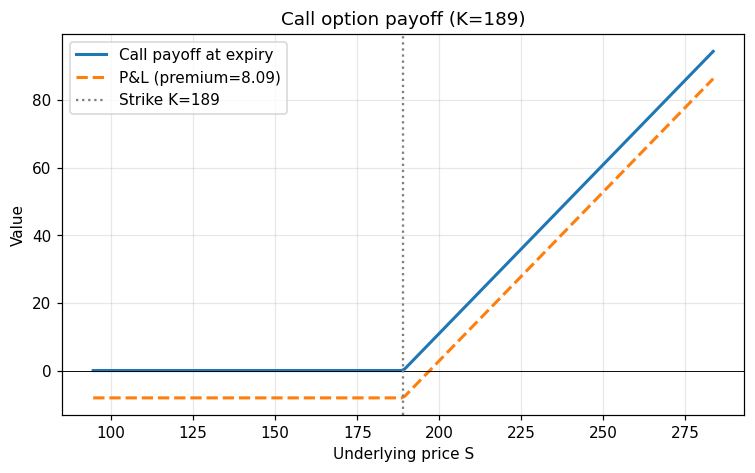

In [ ]:
# Chart 1 : Option Payoff
plot_payoff(K=189, option_type='call', premium=8.09)
plt.show()

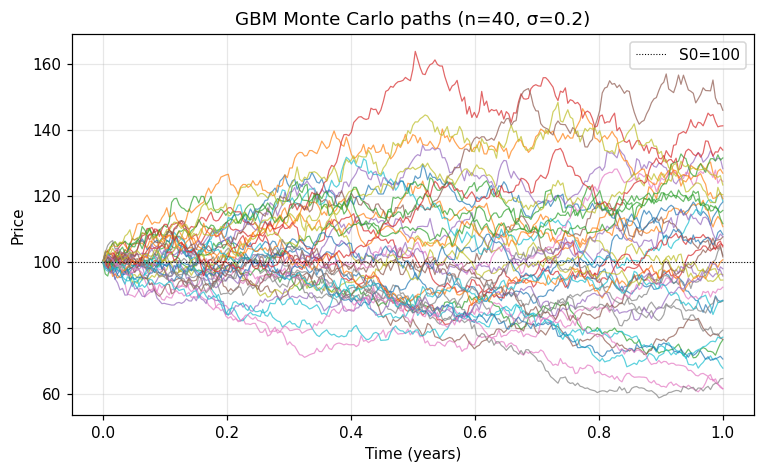

In [ ]:
# Chart 2 : Monte Carlo GBM Paths
plot_mc_paths(S=100, T=1.0, r=0.05, sigma=0.20, paths=40, seed=42)
plt.show()

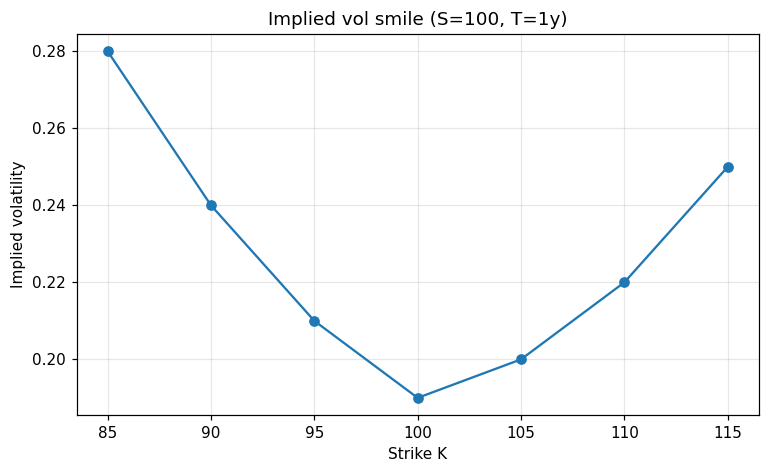

In [ ]:
# Chart 3 : Implied Volatility Smile
# Build smile: use bs_price (not bs_call) with option_type='call'
from quantadesh.models.black_scholes import bs_price
S, T, r = 100, 1.0, 0.05
strikes    = [85, 90, 95, 100, 105, 110, 115]
smile_vols = [0.28, 0.24, 0.21, 0.19, 0.20, 0.22, 0.25]
prices_dict = {K: bs_price(S, K, T, r, v, option_type='call')
               for K, v in zip(strikes, smile_vols)}
plot_vol_smile(S=S, T=T, r=r, prices=prices_dict, option_type='call')
plt.show()

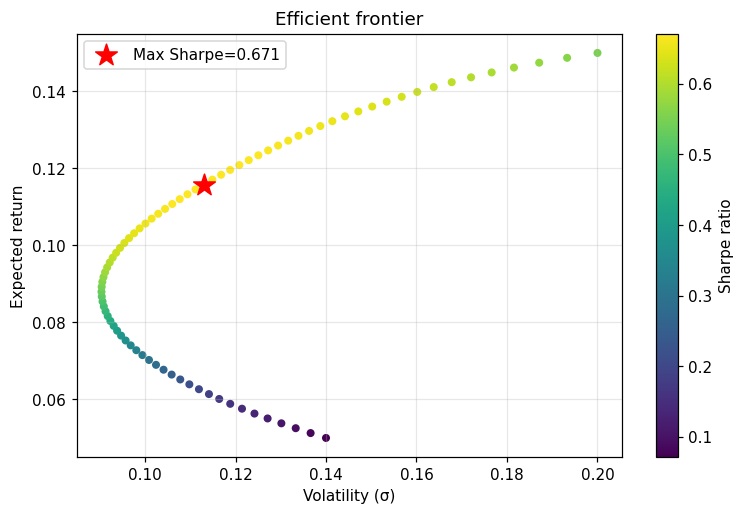

In [ ]:
# Chart 4 : Efficient Frontier
from quantadesh.portfolio.markowitz import efficient_frontier
mu  = np.array([0.15, 0.13, 0.12, 0.10, 0.05])
cov = np.array([
    [0.0400, 0.0180, 0.0150, 0.0080, -0.0020],
    [0.0180, 0.0324, 0.0140, 0.0090, -0.0015],
    [0.0150, 0.0140, 0.0289, 0.0070, -0.0010],
    [0.0080, 0.0090, 0.0070, 0.0225,  0.0005],
    [-0.002,-0.0015,-0.0010, 0.0005,  0.0196],
])
frontier = efficient_frontier(mu, cov, rf=0.04, n_points=80)
plot_efficient_frontier(frontier, rf=0.04)
plt.show()

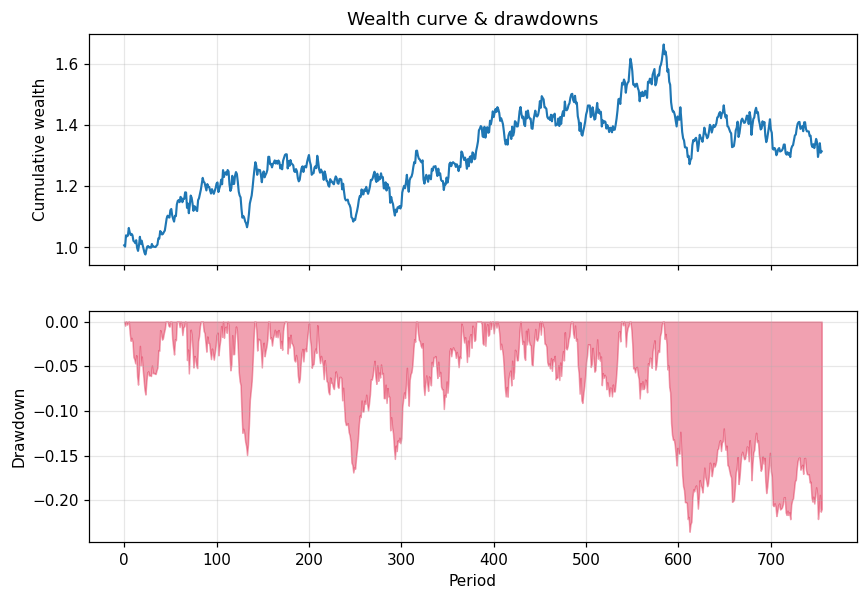

In [ ]:
# Chart 5 : Drawdown
np.random.seed(5)
plot_drawdown(np.random.normal(0.0005, 0.015, 756))
plt.show()

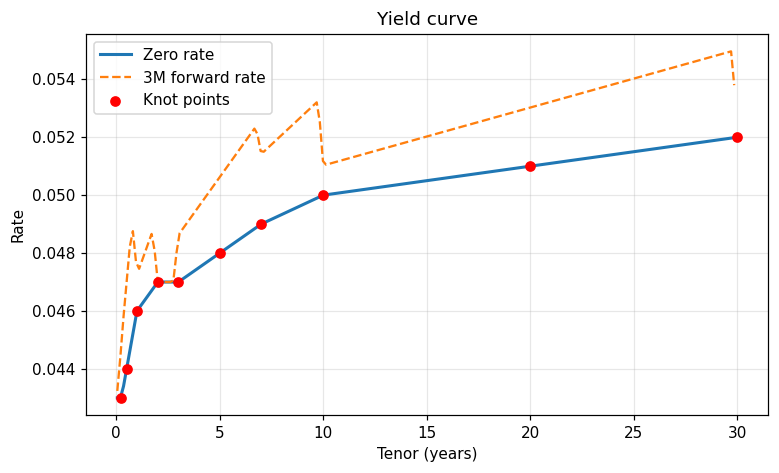

In [ ]:
# Chart 6 : Yield Curve
from quantadesh.fixed_income.curve import YieldCurve
curve = YieldCurve(
    [0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30],
    [0.043, 0.044, 0.046, 0.047, 0.047, 0.048, 0.049, 0.050, 0.051, 0.052]
)
plot_yield_curve(curve, t_max=30)
plt.show()

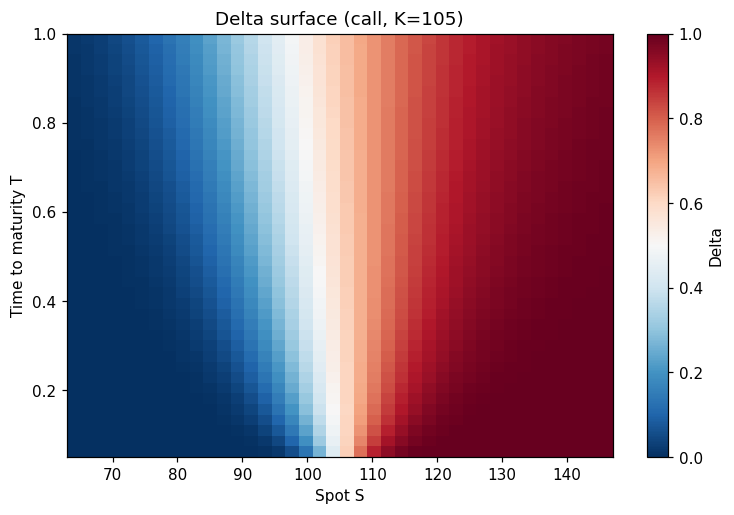

In [ ]:
# Chart 7 : Greeks Surface (Delta heatmap across spot and time)
plot_greeks_surface(K=105, T=1.0, r=0.05, sigma=0.20,
                    option_type='call', greek='delta')
plt.show()
# Also try greek='gamma', 'vega', 'theta', 'rho'

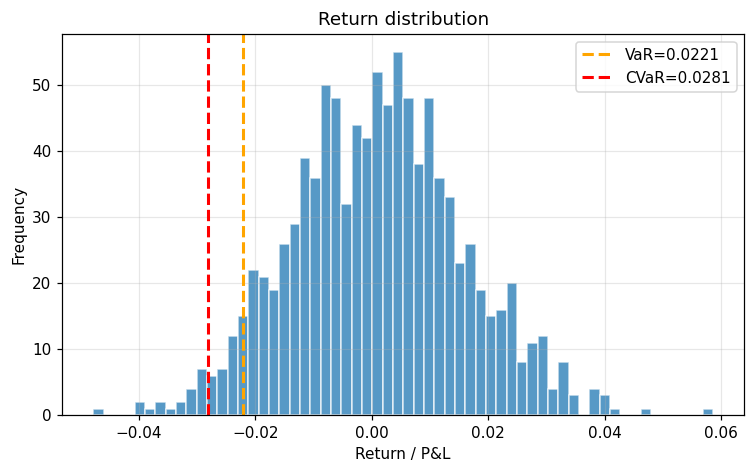

VaR(95%)=0.0221  CVaR(95%)=0.0281


In [ ]:
# Chart 8 : P&L Distribution with VaR and CVaR overlays
from quantadesh.risk.var  import historical_var
from quantadesh.risk.cvar import historical_cvar
np.random.seed(42)
rets = np.random.normal(0.0008, 0.015, 1000)
var_val  = historical_var( rets, confidence=0.95).value
cvar_val = historical_cvar(rets, confidence=0.95).value
plot_pnl_distribution(rets, var_value=var_val, cvar_value=cvar_val)
plt.show()
print(f"VaR(95%)={var_val:.4f}  CVaR(95%)={cvar_val:.4f}")

---
## Quick Reference
```python
# OPTIONS
bs_price(S, K, T, r, sigma, option_type='call')        # Black-Scholes
bs_implied_vol(mkt_price, S, K, T, r, option_type)     # Implied vol
binomial_price(S, K, T, r, sigma, steps=200)           # Binomial tree
mc_price(S, K, T, r, sigma, paths=100_000)             # Monte Carlo
heston_price(S, K, T, r, v0, kappa, theta, sigma, rho) # Heston
bachelier_price(S, K, T, r, sigma=S*0.20)              # Bachelier
black76_price(F, K, T, r, sigma)                       # Black-76

# EXOTICS
asian_price(S, K, T, r, sigma, average_type='arithmetic')
barrier_price(S, K, H, T, r, sigma, barrier_type='up-and-out')
lookback_price(S, T, r, sigma)                         # no K needed
digital_price(S, K, T, r, sigma, cash=1.0)

# GREEKS : only bs_greeks() exists, access via .delta .gamma etc.
bs_greeks(S, K, T, r, sigma, option_type='call')       # returns GreeksResult
numerical_greeks(bs_price, S, K, T, r, sigma)          # pass any pricer

# PORTFOLIO
min_variance(mu, cov, assets=assets, rf=rf)
max_sharpe(mu, cov, rf=rf)
efficient_frontier(mu, cov, rf=rf, n_points=50)
black_litterman(cov, market_weights, P, Q)
capm_beta(asset_returns, market_returns)

# RISK
historical_var(returns, confidence=0.95)   # .value to get float
parametric_var(returns, confidence=0.95)
historical_cvar(returns, confidence=0.95)
max_drawdown(returns)

# RATES : hull_white needs theta as float or callable
vasicek_simulate(r0, a, b, sigma, T, steps, paths)
cir_simulate(r0, a, b, sigma, T, steps, paths)
hull_white_simulate(r0, a, sigma, theta=0.03, T, steps, paths)
```